In [1]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad


import xobjects as xo
import xtrack as xt
import xpart as xp
import xcoll as xc

import pandas as pd

# Make a context and get a buffer
context = xo.ContextCpu()         # For CPU
# context = xo.ContextCupy()      # For CUDA GPUs
# context = xo.ContextPyopencl()  # For OpenCL GPUs

In [2]:
num_part = int(10000)
x_init = 0.002 * np.ones(num_part)
px_init = np.zeros(num_part)
y_init   = np.zeros(num_part)
py_init  = np.zeros(num_part)

def initialize_particles(context, num_particles=num_part):
    return xp.Particles(
        _context=context,
        x=x_init,  
        px=px_init, 
        y=y_init,
        py=py_init,
        delta=0,
        p0c=4e11
    )
    

In [3]:
# Define the crystal properties (initial values)
length = 0.002
material = xc.materials.SiliconCrystal
bending_angle = 440e-6 / 5
width = 0.002
height = 0.05
side = '+'
miscut = 0.0
lattice = 'strip'
jaw = 0.001

In [4]:
# Dataframe to store particle tracking information
columns = ['iteration', 'particle_id', 'x', 'px']
tracking_data = pd.DataFrame(columns=columns)

In [5]:

min_angle = -20
max_angle = 20
steps = 1
# Define the range of bending angles to iterate over
impacting_angles = [i * 1e-6 for i in range(min_angle, max_angle, steps)]  # Example: 100 µrad to 200 µrad in 10 µrad steps


In [6]:

# List to collect all tracking data
tracking_data_list = []
critical_angle = 0

# Loop over bending angles
for iteration, angle in enumerate(impacting_angles):
    # Create the crystal with the current bending angle
    coll = xc.EverestCrystal(
        length=length,
        material=material,
        bending_angle=bending_angle,
        width=width,
        height=height,
        side=side,
        miscut=miscut,
        lattice=lattice,
        tilt = angle,    #IMPORTANT
        jaw=jaw,
        _context=context
    )
    
    # Initialize a new beam of particles for this iteration
    part = initialize_particles(context)
    part_init = part.copy()
    
    # Track particles through the crystal
    coll.track(part)  # Updates the particle states in place
    
    # Collect particle data for this iteration
    for i in range(len(part.x)):
        tracking_data_list.append({
            'iteration': iteration,
            'particle_id': i,
            'x': part.x[i],
            'px': part.px[i],
            'px_init': part_init.px[i],
            'angle': angle
        })
    print(str(iteration))
    critical_angle = coll.critical_angle
# Convert the collected data into a DataFrame
tracking_data = pd.DataFrame(tracking_data_list)


0
The critical angle of the crystal is: 9.39055258888153e-06
1
The critical angle of the crystal is: 9.39055258888153e-06
2
The critical angle of the crystal is: 9.39055258888153e-06
3
The critical angle of the crystal is: 9.39055258888153e-06
4
The critical angle of the crystal is: 9.39055258888153e-06
5
The critical angle of the crystal is: 9.39055258888153e-06
6
The critical angle of the crystal is: 9.39055258888153e-06
7
The critical angle of the crystal is: 9.39055258888153e-06
8
The critical angle of the crystal is: 9.39055258888153e-06
9
The critical angle of the crystal is: 9.39055258888153e-06
10
The critical angle of the crystal is: 9.39055258888153e-06
11
The critical angle of the crystal is: 9.39055258888153e-06
12
The critical angle of the crystal is: 9.39055258888153e-06
13
The critical angle of the crystal is: 9.39055258888153e-06
14
The critical angle of the crystal is: 9.39055258888153e-06
15
The critical angle of the crystal is: 9.39055258888153e-06
16
The critical an

In [7]:
# Perform analysis or save the DataFrame
print(tracking_data.head())


   iteration  particle_id      x        px  px_init    angle
0          0            0  0.002 -0.000016      0.0 -0.00002
1          0            1  0.002 -0.000012      0.0 -0.00002
2          0            2  0.002 -0.000021      0.0 -0.00002
3          0            3  0.002 -0.000017      0.0 -0.00002
4          0            4  0.002 -0.000012      0.0 -0.00002


In [8]:
tracking_data

,iteration,particle_id,x,px,px_init,angle
0,0,0,0.002,-0.000016,0.0,-0.000020
1,0,1,0.002,-0.000012,0.0,-0.000020
2,0,2,0.002,-0.000021,0.0,-0.000020
3,0,3,0.002,-0.000017,0.0,-0.000020
4,0,4,0.002,-0.000012,0.0,-0.000020
...,...,...,...,...,...,...
399995,39,9995,0.002,0.000001,0.0,0.000019
399996,39,9996,0.002,0.000006,0.0,0.000019
399997,39,9997,0.002,0.000004,0.0,0.000019
399998,39,9998,0.002,0.000003,0.0,0.000019


In [9]:
# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Initialize required variables
BendingAngle = bending_angle * 1.e6
print(f"The bending angle of the crystal is: {BendingAngle} murad")
efficiencies = []  # List to store calculated efficiencies
efficiencies_error = []
impacting_angle = []

# Loop over iterations for efficiency analysis
for iteration in tracking_data['iteration'].unique():
    # Extract data for the current iteration
    iteration_data = tracking_data[tracking_data['iteration'] == iteration]

    if iteration_data['angle'].isnull().any():
        print(f"Iteration {iteration}: Invalid 'angle' data. Skipping.")
        efficiencies.append(np.nan)
        continue

    # Calculate crystal angle
    crystal_angle = iteration_data['angle'].unique().item() * 1.e6
    print(f"The crystal angle is: {crystal_angle} murad")
    px_values = iteration_data['px'] * 1.e6 
    px_init_values = iteration_data['px_init'] *1.e6
    crystal_angle = iteration_data['angle'].unique().item() * 1.e6
    print(f"crystal_angle: {crystal_angle} mrad")   

    # Select only surviving particles and only within the window of interest
    mask = (px_values > -BendingAngle) & ((px_values - part_init.px) < BendingAngle * 2) & ((px_values - part_init.px) > -100)
    channeling_px = px_values[mask]   # Convert to µrad

    # Generate the histogram data for plotting and fitting
    counts, bin_edges = np.histogram(channeling_px, bins=2000, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    # Restrict fitting to the peak range
    mask_fit = (bin_centers >= crystal_angle + BendingAngle * 0.8) & (bin_centers <= crystal_angle + BendingAngle * 1.2)
    bin_centers_fit = bin_centers[mask_fit]
    counts_fit = counts[mask_fit]
    #print(counts_fit)

    # Perform Gaussian fit within the specified range
    try:
        initial_guess = [np.max(counts_fit), crystal_angle + BendingAngle, 5]
        popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit, p0=initial_guess,
                       bounds=([0, BendingAngle*0.8 + crystal_angle, 1], [np.inf,  BendingAngle*1.2 + crystal_angle, 10]))
        print(f"Bin with biggest count: {np.argmax(counts_fit)}")

        # Extract fit parameters and errors
        amp, mean, sigma = popt
        amp_err, mean_err, sigma_err = np.sqrt(np.diag(pcov))

        # Calculate the integral (number of channeled particles) and its error
        integral = amp * sigma * np.sqrt(2 * np.pi) / bin_width                         #IMPORTANT TO DIVEDE BY BIN_WIDTH
        integral_error = integral * np.sqrt((amp_err / amp)**2 + (sigma_err / sigma)**2) 

        # Calculate efficiency for the main peak relative to total particles in the range
        efficiency = integral / num_part * 100
        if efficiency > 100:
            efficiency = 0
            efficiencies.append(efficiency)
        efficiencies.append(efficiency)
        print(f"Efficiency of {iteration} iteration: {efficiency:.2f}%")
    except Exception as e:
        # Handle any error by setting efficiency to 0
        efficiency = 0
        efficiencies.append(efficiency)
        print(f"Failed to calculate efficiency for iteration {iteration}. Setting efficiency to 0. Error: {e}")
        
     # Plot the histogram and the Gaussian fit only in the fitting range
    #plt.figure(figsize=(8, 6))
    #plt.hist(channeling_px, bins=2000, density=False, color='blue', edgecolor='blue')

    
    # Ideal efficiency calculated as particles insed range +- 3 sigma of the integral 
    lower_bound = mean - 3 * sigma
    upper_bound = mean + 3 * sigma
    particles_in_range = len(channeling_px[(channeling_px >= lower_bound) & (channeling_px <= upper_bound)])
    ideal_efficiency = (particles_in_range / num_part) * 100

    # Generate impacting angle data
    impacting_angle.append(min_angle + iteration * steps)
    #print(f"Impacting angle: {impacting_angle}")

    # Save efficiencies to DataFrame
    efficiency_data = pd.DataFrame({
    'impacting angle (muRad)': impacting_angle,
    'efficiency': efficiencies
    })

# Display efficiency data
print(efficiency_data)


The bending angle of the crystal is: 88.0 murad
The crystal angle is: -20.0 murad
crystal_angle: -20.0 mrad
Bin with biggest count: 135
Efficiency of 0 iteration: 0.39%
The crystal angle is: -18.999999999999996 murad
crystal_angle: -18.999999999999996 mrad
Bin with biggest count: 195
Efficiency of 1 iteration: 0.45%
The crystal angle is: -18.0 murad
crystal_angle: -18.0 mrad
Bin with biggest count: 83
Efficiency of 2 iteration: 0.41%
The crystal angle is: -17.0 murad
crystal_angle: -17.0 mrad
Bin with biggest count: 181
Efficiency of 3 iteration: 0.31%
The crystal angle is: -16.0 murad
crystal_angle: -16.0 mrad
Bin with biggest count: 193
Efficiency of 4 iteration: 0.27%
The crystal angle is: -14.999999999999998 murad
crystal_angle: -14.999999999999998 mrad
Bin with biggest count: 162
Efficiency of 5 iteration: 0.40%
The crystal angle is: -14.0 murad
crystal_angle: -14.0 mrad
Bin with biggest count: 125
Efficiency of 6 iteration: 0.43%
The crystal angle is: -13.0 murad
crystal_angle: -

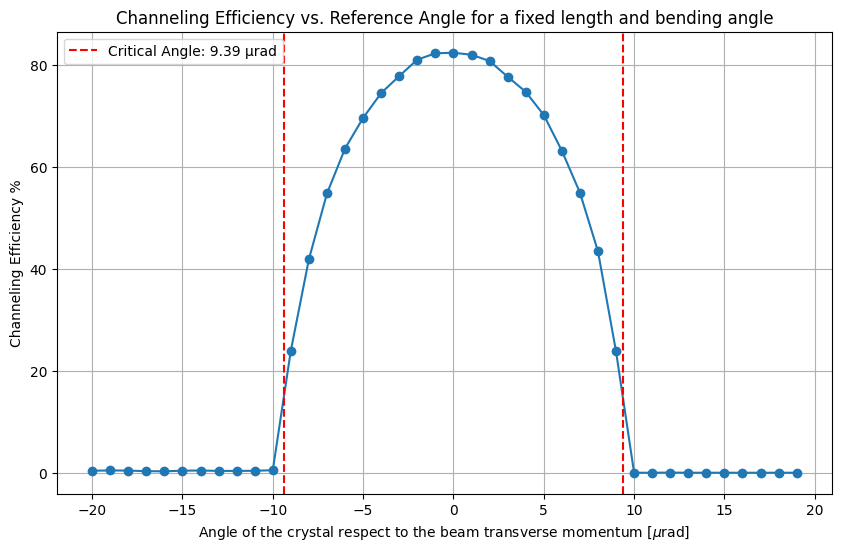

In [11]:
# Ensure efficiencies and bending angles are in the same order
efficiency_data['bending_angle'] = [angle for angle in impacting_angles]  

# Plot Channeling Efficiency vs Bending Angle
plt.figure(figsize=(10, 6))
plt.plot(efficiency_data['bending_angle']*1.e6, efficiency_data['efficiency'], marker='o', linestyle='-')
# Add a vertical line for the critical angle
plt.axvline(x = critical_angle * 1.e6, color='red', linestyle='--', label=f'Critical Angle: {critical_angle * 1.e6:.2f} µrad')
# Add a vertical line for the critical angle
plt.axvline(x= - critical_angle * 1.e6, color='red', linestyle='--')


# Customize the plot
plt.title('Channeling Efficiency vs. Reference Angle for a fixed length and bending angle')
plt.xlabel(r'Angle of the crystal respect to the beam transverse momentum [$\mu$rad]')
plt.ylabel('Channeling Efficiency %')
plt.legend()
plt.grid(True)
plt.show()

## Tests and debug

Let's see if initializing a bunch of particles passing through a crystal we can fit the channeling mode.

In [12]:
crystal = xc.EverestCrystal(length = 0.002,
material = xc.materials.SiliconCrystal,
bending_angle = 440e-6 / 5,
width = 0.002,
height = 0.05,
side = '+',
miscut = 0.0,
lattice = 'strip',
jaw = 0.001,         
#tilt = -1.9999999999999998e-05,  
tilt = 0 ,    
_context=context)

part = xp.Particles(
        _context=context,
        x=x_init,  
        px=px_init, 
        y=y_init,
        py=py_init,
        delta=0,
        p0c=4e11
    )
part_init = part.copy()


In [13]:
crystal.track(part)

In [14]:
# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Initialize required variables
BendingAngle = bending_angle * 1.e6
print(f"The bending angle of the crystal is: {BendingAngle} murad")
efficiencies = []  # List to store calculated efficiencies
impacting_angle = []

# Loop over iterations for efficiency analysis
for iteration in tracking_data['iteration'].unique():
    # Extract data for the current iteration
    iteration_data = tracking_data[tracking_data['iteration'] == iteration]

    if iteration_data['angle'].isnull().any():
        print(f"Iteration {iteration}: Invalid 'angle' data. Skipping.")
        efficiencies.append(0)  # Maintain consistent length with 0 for invalid data
        impacting_angle.append(min_angle + iteration * steps)  # Append impacting angle
        continue

    # Calculate crystal angle
    crystal_angle = iteration_data['angle'].unique().item() * 1.e6
    print(f"The crystal angle is: {crystal_angle} murad")
    px_values = iteration_data['px'] * 1.e6
    px_init_values = iteration_data['px_init'] * 1.e6

    # Select only surviving particles and only within the window of interest
    mask = (px_values > -BendingAngle) & ((px_values - part_init.px) < BendingAngle * 2) & ((px_values - part_init.px) > -100)
    channeling_px = px_values[mask]

    # Generate the histogram data for plotting and fitting
    counts, bin_edges = np.histogram(channeling_px, bins=2000, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    # Restrict fitting to the peak range
    mask_fit = (bin_centers >=  BendingAngle * 0.8) & (bin_centers <= BendingAngle * 1.2)
    bin_centers_fit = bin_centers[mask_fit]
    counts_fit = counts[mask_fit]

    # Perform Gaussian fit within the specified range
    try:
        initial_guess = [np.max(counts_fit),  BendingAngle, 5]
        popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit, p0=initial_guess,
                               bounds=([0, BendingAngle * 0.8 , 1], [np.inf, BendingAngle * 1.2 , 10]))
        amp, mean, sigma = popt

        # Calculate the integral (number of channeled particles)
        integral = amp * sigma * np.sqrt(2 * np.pi) / bin_width
        efficiency = (integral / num_part) * 100

        # Check if efficiency is greater than 100%
        if efficiency > 100:
            print(f"Efficiency greater than 100% detected for iteration {iteration}. Setting efficiency to 0.")
            efficiency = 0  # Set efficiency to 0 in case of an invalid value

    except Exception as e:
        print(f"Failed to calculate efficiency for iteration {iteration}. Setting efficiency to 0. Error: {e}")
        efficiency = 0  # Set efficiency to 0 in case of an error

    # Append results consistently
    efficiencies.append(efficiency)
    impacting_angle.append(min_angle + iteration * steps)

# Save efficiencies to DataFrame
efficiency_data = pd.DataFrame({
    'impacting angle (muRad)': impacting_angle,
    'efficiency': efficiencies
})

# Display efficiency data
print(efficiency_data)


The bending angle of the crystal is: 88.0 murad
The crystal angle is: -20.0 murad
The crystal angle is: -18.999999999999996 murad
The crystal angle is: -18.0 murad
The crystal angle is: -17.0 murad
The crystal angle is: -16.0 murad
The crystal angle is: -14.999999999999998 murad
The crystal angle is: -14.0 murad
The crystal angle is: -13.0 murad
The crystal angle is: -12.0 murad
The crystal angle is: -11.0 murad
The crystal angle is: -10.0 murad
The crystal angle is: -9.0 murad
The crystal angle is: -8.0 murad
The crystal angle is: -7.0 murad
The crystal angle is: -6.0 murad
The crystal angle is: -5.0 murad
The crystal angle is: -4.0 murad
The crystal angle is: -3.0 murad
The crystal angle is: -2.0 murad
The crystal angle is: -1.0 murad
The crystal angle is: 0.0 murad
The crystal angle is: 1.0 murad
The crystal angle is: 2.0 murad
The crystal angle is: 3.0 murad
The crystal angle is: 4.0 murad
The crystal angle is: 5.0 murad
The crystal angle is: 6.0 murad
The crystal angle is: 7.0 mur

#### Let's try with the data that we have from before

Let's see if we can analyse just one iteration of the previous dataframe

In [15]:
iteration_data = tracking_data[tracking_data['iteration'] == 17]

In [16]:
crystal_angle = iteration_data['angle'].unique().item()

In [17]:
crystal_angle

-3e-06

In [18]:
iteration_data

,iteration,particle_id,x,px,px_init,angle
170000,17,0,0.002,0.000084,0.0,-0.000003
170001,17,1,0.002,0.000091,0.0,-0.000003
170002,17,2,0.002,0.000077,0.0,-0.000003
170003,17,3,0.002,0.000094,0.0,-0.000003
170004,17,4,0.002,-0.000007,0.0,-0.000003
...,...,...,...,...,...,...
179995,17,9995,0.002,-0.000004,0.0,-0.000003
179996,17,9996,0.002,-0.000006,0.0,-0.000003
179997,17,9997,0.002,-0.000011,0.0,-0.000003
179998,17,9998,0.002,-0.000004,0.0,-0.000003


BendingAngle: 88.0 mrad
crystal_angle: -3.0 mrad
[ 1  0  1  2  0  0  1  0  0  2  0  0  0  0  0  0  1  0  0  0  0  0  0  0
  0  0  1  0  1  0  0  1  0  0  0  1  0  0  2  1  0  2  0  0  3  1  2  1
  2  0  0  2  1  1  0  0  0  1  0  2  0  0  0  1  1  0  1  2  0  1  0  0
  1  1  2  4  1  0  1  3  1  1  0  4  2  2  2  5  1  1  3  4  2  0  0  0
  3  0  1  3  1  5  5  1  3  1  3  3  5  4  4  4  4  4  8  4  2  3  6  7
  3  6  8  5  3  5  9  3  6  5  7  3  4  6 11  5  6 11  5  6  9  5  8  5
  9  7  4 13 10 17 10 13  6 11 14  8 14 15 11 19 19 12 15 16 16 14 20 21
 18 19 21 14 21 17 18 17 15 13 20 24 15 17 23 16 18 19 26 21 28 21 19 28
 33 30 26 26 19 22 32 19 21 26 25 32 25 33 33 26 24 23 24 20 16 44 40 25
 34 28 27 37 30 34 36 31 42 30 37 38 41 32 44 25 39 40 42 44 44 27 35 48
 44 37 36 45 24 32 45 33 42 34 45 48 38 35 46 37 44 53 51 43 52 38 41 34
 48 55 42 58 39 34 30 36 56 47 42 46 53 35 40 43 46 44 51 49 37 52 39 25
 31 48 35 36 44 41 39 34 45 46 43 34 37 40 41 42 38 24 57 28 53 37 43 30
 4

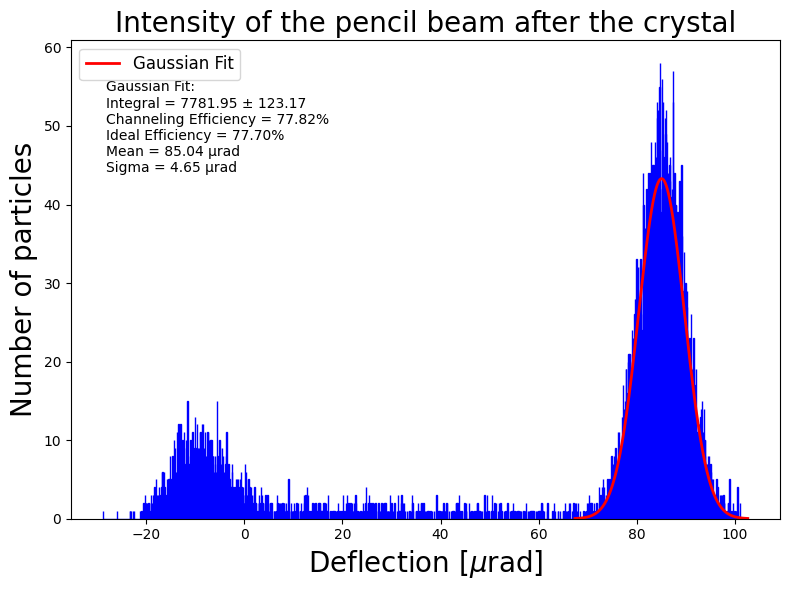

Number of channeled particles (integral of the fit): 7781.95 ± 123.17
Channeling Efficiency: 77.82%
Ideal Efficiency: 77.70%
Fit parameters: Amplitude = 43.30, Mean = 85.04, Sigma = 4.65


In [19]:
BendingAngle = crystal.bending_angle *1.e6
print(f"BendingAngle: {BendingAngle} mrad")


# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2))

px_values = iteration_data['px'] * 1.e6 
px_init_values = iteration_data['px_init'] *1.e6
crystal_angle = iteration_data['angle'].unique().item() * 1.e6
print(f"crystal_angle: {crystal_angle} mrad")   

# Select only surviving particles and only within the window of interest
mask = (px_values > -BendingAngle) & ((px_values - part_init.px) < BendingAngle * 2) & ((px_values - part_init.px) > -100)
channeling_px = px_values[mask]   # Convert to µrad

# Generate the histogram data for plotting and fitting
counts, bin_edges = np.histogram(channeling_px, bins=2000, density=False)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Restrict fitting to the peak range
mask_fit = (bin_centers >= crystal_angle + BendingAngle * 0.8) & (bin_centers <= crystal_angle + BendingAngle * 1.2)
bin_centers_fit = bin_centers[mask_fit]
counts_fit = counts[mask_fit]
print(counts_fit)

# Perform Gaussian fit within the specified range
initial_guess = [np.max(counts_fit), crystal_angle + BendingAngle, 5]
popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit, p0=initial_guess,
                       bounds=([0, BendingAngle*0.8 + crystal_angle, 1], [np.inf,  BendingAngle*1.2 + crystal_angle, 10]))
print(f"Bin with biggest count: {np.argmax(counts_fit)}")

# Extract fit parameters and errors
amp, mean, sigma = popt
amp_err, mean_err, sigma_err = np.sqrt(np.diag(pcov))

# Plot the histogram and the Gaussian fit only in the fitting range
plt.figure(figsize=(8, 6))
plt.hist(channeling_px, bins=2000, density=False, color='blue', edgecolor='blue')

# Plot the Gaussian fit 
plot_range = np.linspace(crystal_angle + BendingAngle*0.8, crystal_angle + BendingAngle*1.2, 2000)
plt.plot(plot_range, gaussian(plot_range, *popt), color='red', linewidth=2, label="Gaussian Fit")

# Calculate the integral (number of channeled particles) and its error
integral = amp * sigma * np.sqrt(2 * np.pi) / bin_width                         #IMPORTANT TO DIVEDE BY BIN_WIDTH
integral_error = integral * np.sqrt((amp_err / amp)**2 + (sigma_err / sigma)**2) 

# Calculate efficiency for the main peak relative to total particles in the range
efficiency = integral / num_part * 100
# Ideal efficiency calculated as particles insed range +- 3 sigma of the integral 
lower_bound = mean - 3 * sigma
upper_bound = mean + 3 * sigma
particles_in_range = len(channeling_px[(channeling_px >= lower_bound) & (channeling_px <= upper_bound)])
ideal_efficiency = (particles_in_range / num_part) * 100

# Display fit information on the plot
fit_info = (f"\n"
            f"Gaussian Fit:\n"
            f"Integral = {integral:.2f} ± {integral_error:.2f}\n"
            f"Channeling Efficiency = {efficiency:.2f}%\n"
            f"Ideal Efficiency = {ideal_efficiency:.2f}%\n"
            f"Mean = {mean:.2f} µrad\n"
            f"Sigma = {sigma:.2f} µrad")
plt.text(0.05, 0.95, fit_info, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

# Final plot adjustments
plt.xlabel(r'Deflection [$\mu$rad]', fontsize=20)
#plt.xlim(crystal_angle - BendingAngle, crystal_angle + BendingAngle * 1.2)
plt.ylabel('Number of particles', fontsize=20)
plt.title(r'Intensity of the pencil beam after the crystal', fontsize=20)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

# Print the results
print(f"Number of channeled particles (integral of the fit): {integral:.2f} ± {integral_error:.2f}")
print(f"Channeling Efficiency: {efficiency:.2f}%")
print(f"Ideal Efficiency: {ideal_efficiency:.2f}%")
print(f"Fit parameters: Amplitude = {amp:.2f}, Mean = {mean:.2f}, Sigma = {sigma:.2f}")
